## Tools & ToolNode in LangGraph


In [ ]:
from langchain_core.tools import tool


# ─────────────────────────────────────────────────────
# 🔷 TOOLS
# Tools are specialised functions agents use to perform
# tasks like fetching data, doing calculations, querying DBs.
# @tool decorator:
#   - Makes a regular function into a LangChain Tool
#   - The DOCSTRING becomes the description the LLM reads
#     to decide when and how to call the tool
# ─────────────────────────────────────────────────────


@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    db = {
        "bhopal": "30°C ☀️",
        "mumbai": "28°C 🌫️",
        "delhi": "25°C ⛅",
        "london": "12°C 🌧️",
    }
    result = db.get(city.lower(), f"No data for '{city}'")
    print(f"  ⚙️  get_weather({city!r}) → {result}")
    return result


@tool
def calculate(expression: str) -> str:
    """Evaluate a basic math expression like '2 + 2 * 10'."""
    try:
        result = str(eval(expression))
        print(f"  ⚙️  calculate({expression!r}) → {result}")
        return result
    except Exception as e:
        return f"Error: {e}"


tools = [get_weather, calculate]

# Inspect a tool's properties
print("🔧 Tool inspection:")
print(f"  name        : {get_weather.name}")
print(f"  description : {get_weather.description}")
print(f"  args schema : {get_weather.args_schema.model_json_schema()['properties']}")

from langgraph.prebuilt import ToolNode

# ─────────────────────────────────────────────────────
# 🔷 TOOLNODE
# A ToolNode is a special node whose ONLY job is to RUN tools.
# It:
#   1. Reads the last AIMessage from state
#   2. Finds its .tool_calls list
#   3. Calls each tool with the provided arguments
#   4. Returns ToolMessage(s) with the results
# It does NOT call the LLM — that's the agent node's job.
# ─────────────────────────────────────────────────────
tool_node = ToolNode(tools)

🔧 Tool inspection:
  name        : get_weather
  description : Get the current weather for a given city.
  args schema : {'city': {'title': 'City', 'type': 'string'}}


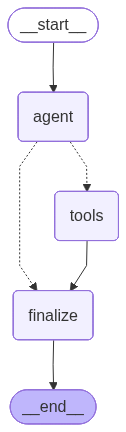

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, BaseMessage
from typing import TypedDict, Annotated
import operator


# --- 2. TOOLNODE IN A GRAPH ---
# We build a minimal graph to demonstrate ToolNode.
# The simulate_agent node manually crafts an AIMessage with
# tool_calls — exactly what a real LLM would produce.
# ToolNode reads those tool_calls, runs the tools, and returns
# ToolMessage(s) — all automatically.


class State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]


def simulate_agent(state: State) -> dict:
    """Manually creates an AIMessage with tool_calls (no LLM needed for demo)"""
    user_text = state["messages"][-1].content.lower()
    if "weather" in user_text:
        ai_msg = AIMessage(
            content="",
            tool_calls=[
                {
                    "name": "get_weather",
                    "args": {"city": "Bhopal"},
                    "id": "call_w1",
                }
            ],
        )
    elif "calc" in user_text or "math" in user_text:
        ai_msg = AIMessage(
            content="",
            tool_calls=[
                {
                    "name": "calculate",
                    "args": {"expression": "99 * 42"},
                    "id": "call_c1",
                }
            ],
        )
    else:
        ai_msg = AIMessage(content="I can help with weather or math!")
    return {"messages": [ai_msg]}


def finalize(state: State) -> dict:
    print(f"     {state['messages']}")
    tool_msgs = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    if tool_msgs:
        return {"messages": [AIMessage(content=f"Result: {tool_msgs[-1].content}")]}
    return {}


def should_use_tools(state: State) -> str:
    last = state["messages"][-1]
    return "tools" if (isinstance(last, AIMessage) and last.tool_calls) else "finalize"


builder = StateGraph(State)
# Nodes
builder.add_node("agent", simulate_agent)
builder.add_node("tools", tool_node)
builder.add_node("finalize", finalize)
# Edges
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_use_tools, {"tools": "tools", "finalize": "finalize"})
builder.add_edge("tools", "finalize")
builder.add_edge("finalize", END)
# Compile
graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
for q in [
    "What's the weather in Bhopal?",
    "Do some math for me!",
    "Hello World",
]:
    print(f"\n❓ {q}")
    r = graph.invoke({"messages": [HumanMessage(q)]})
    print(f"✅ {r['messages'][-1].content}")


❓ What's the weather in Bhopal?
  ⚙️  get_weather('Bhopal') → 30°C ☀️
     [HumanMessage(content="What's the weather in Bhopal?", additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'get_weather', 'args': {'city': 'Bhopal'}, 'id': 'call_w1', 'type': 'tool_call'}], invalid_tool_calls=[]), ToolMessage(content='30°C ☀️', name='get_weather', tool_call_id='call_w1')]
✅ Result: 30°C ☀️

❓ Do some math for me!
  ⚙️  calculate('99 * 42') → 4158
     [HumanMessage(content='Do some math for me!', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'calculate', 'args': {'expression': '99 * 42'}, 'id': 'call_c1', 'type': 'tool_call'}], invalid_tool_calls=[]), ToolMessage(content='4158', name='calculate', tool_call_id='call_c1')]
✅ Result: 4158

❓ Hello World
     [HumanMessage(content='Hello World', additional_kwargs={}, response_metadata=